In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

import pandas as pd

In [24]:
# from transformers import EsmTokenizer, EsmForSequenceClassification
# import torch

# MODEL_NAME = "facebook/esm2_t12_35M_UR50D"

# # Tokenizer
# tokenizer = EsmTokenizer.from_pretrained(MODEL_NAME)

# # Model with a regression head
# model = EsmForSequenceClassification.from_pretrained(
#     MODEL_NAME,
#     num_labels=1,
#     problem_type="regression"
# )

In [ ]:
#differnt schemes
from transformers import AutoTokenizer
from model import MODEL_NAME, get_dataloader, EVAL_SPLIT

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

batch_size = 16
loaders = {}
for scheme in ["a", "b", "c"]:
    train_loader = get_dataloader(scheme, "predictor_train", tokenizer,
                                  batch_size=batch_size, shuffle=True)
    test_loader = get_dataloader(scheme, EVAL_SPLIT[scheme], tokenizer,
                                 batch_size=batch_size)
    loaders[scheme] = (train_loader, test_loader)
    print(f"scheme {scheme}: "
          f"train {len(train_loader.dataset):>7,} seqs / {len(train_loader):>5,} batches | "
          f"test {len(test_loader.dataset):>7,} seqs / {len(test_loader):>5,} batches")

scheme a: train  44,016 seqs / 2,751 batches | test  14,672 seqs /   917 batches
scheme b: train 220,082 seqs / 13,756 batches | test  73,360 seqs / 4,585 batches
scheme c: train 109,976 seqs / 6,874 batches | test 183,466 seqs / 11,467 batches


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 16083.20it/s]
[transformers] EsmForSequenceClassification LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


device=mps | scheme=a | train batches=157 eval batches=16
freeze_backbone=True | trainable params=231,361 / 33,500,882


epoch 1: train_loss=9.0866 | test_rmse=2.7568 pearson=0.6101 spearman=0.6027


epoch 2: train_loss=7.3255 | test_rmse=2.6726 pearson=0.6354 spearman=0.6266


epoch 3: train_loss=6.8928 | test_rmse=2.6660 pearson=0.6596 spearman=0.6527


epoch 4: train_loss=6.6006 | test_rmse=2.5208 pearson=0.6813 spearman=0.6752


epoch 5: train_loss=6.2276 | test_rmse=2.7104 pearson=0.6982 spearman=0.6956


epoch 6: train_loss=6.1367 | test_rmse=2.4889 pearson=0.7064 spearman=0.7071


epoch 7: train_loss=5.8213 | test_rmse=2.5507 pearson=0.7154 spearman=0.7211


epoch 8: train_loss=5.8852 | test_rmse=2.3773 pearson=0.7229 spearman=0.7280
saved weights -> weights/ghost_a.pt


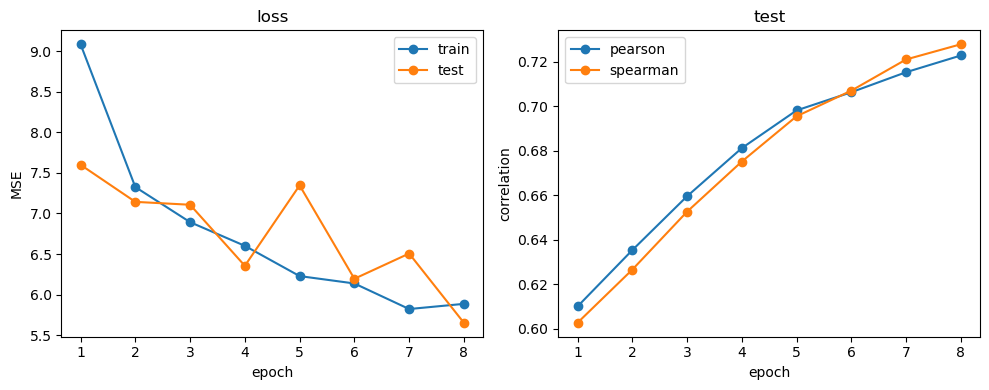

[{'epoch': 1,
  'train_loss': 9.0865968473398,
  'test_mse': 7.6001434326171875,
  'test_rmse': 2.7568357645346206,
  'test_pearson': 0.6100639803834911,
  'test_spearman': 0.6027287422751202},
 {'epoch': 2,
  'train_loss': 7.325497580182021,
  'test_mse': 7.143054008483887,
  'test_rmse': 2.6726492490568017,
  'test_pearson': 0.6353836508759951,
  'test_spearman': 0.6266114957656215},
 {'epoch': 3,
  'train_loss': 6.892752366460813,
  'test_mse': 7.107344150543213,
  'test_rmse': 2.6659602679978582,
  'test_pearson': 0.6596048066184473,
  'test_spearman': 0.6526672293430991},
 {'epoch': 4,
  'train_loss': 6.600600218317311,
  'test_mse': 6.3544697761535645,
  'test_rmse': 2.52080736593528,
  'test_pearson': 0.6812608797027397,
  'test_spearman': 0.6752238784618906},
 {'epoch': 5,
  'train_loss': 6.227611951007964,
  'test_mse': 7.346363544464111,
  'test_rmse': 2.7104175959553007,
  'test_pearson': 0.6982249798075199,
  'test_spearman': 0.6955803673609522},
 {'epoch': 6,
  'train_loss

In [25]:
#ghost test 

from train import train

model, history = train(
    scheme="a",
    out_path="weights/ghost_a.pt",
    epochs=8,
    batch_size=16,
    train_limit=2500,   # subsample trainnig set for test run 
    eval_limit=256,
    lr=1e-3,
    freeze_backbone=True,
    plot=True,         # shows loss + pearson/spearman curves
)
history